# Necessary Imports & Setups

In [11]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
import matplotlib
import os
from datetime import datetime

# Folder containing the CSV exports from "Strain Simulation FEniCSx.ipynb".
# All coordinates in these files are already in the exported convention:
# x = mesh_x - 1.25, y = mesh_y - 108.05, z = -z_mesh - 13 (Ge well: z = 42-58).
SIM_DIR = "simulation_2026-09-08"

# All PDF graphs are saved into graph/<date>/ (created if missing)
GRAPH_DIR = os.path.join("graph", datetime.now().strftime("%Y-%m-%d"))
os.makedirs(GRAPH_DIR, exist_ok=True)


In [12]:
# Download the saved PDF file (Google Colab only — locally the PDF is
# already saved under GRAPH_DIR, so no download is needed)
# from google.colab import files
# files.download(os.path.join(GRAPH_DIR, 'LH-HH_band_gap.pdf'))

In [13]:
# Mount Google Drive (Google Colab only — not needed when running locally)
# from google.colab import drive
# drive.mount('/content/drive')

In [14]:
# Load the strain data (coordinates in these files are already in the
# exported convention, see SIM_DIR above — no shifting needed)
strain_files = {
    'strain_yymxx': f"{SIM_DIR}/strain_2D/strain_yy-xx data.csv",
    'strain_xz': f"{SIM_DIR}/strain_2D/strain_xz data.csv",
    'strain_yz': f"{SIM_DIR}/strain_2D/strain_yz data.csv",
    'strain_xy': f"{SIM_DIR}/strain_2D/strain_xy data.csv",
    'strain_zz': f"{SIM_DIR}/strain_2D/strain_zz data.csv",
    'strain_yypxx': f"{SIM_DIR}/strain_2D/strain_yy+xx data.csv"
}

# Load the data into a dictionary of dataframes
strain_data = {name: pd.read_csv(path) for name, path in strain_files.items()}

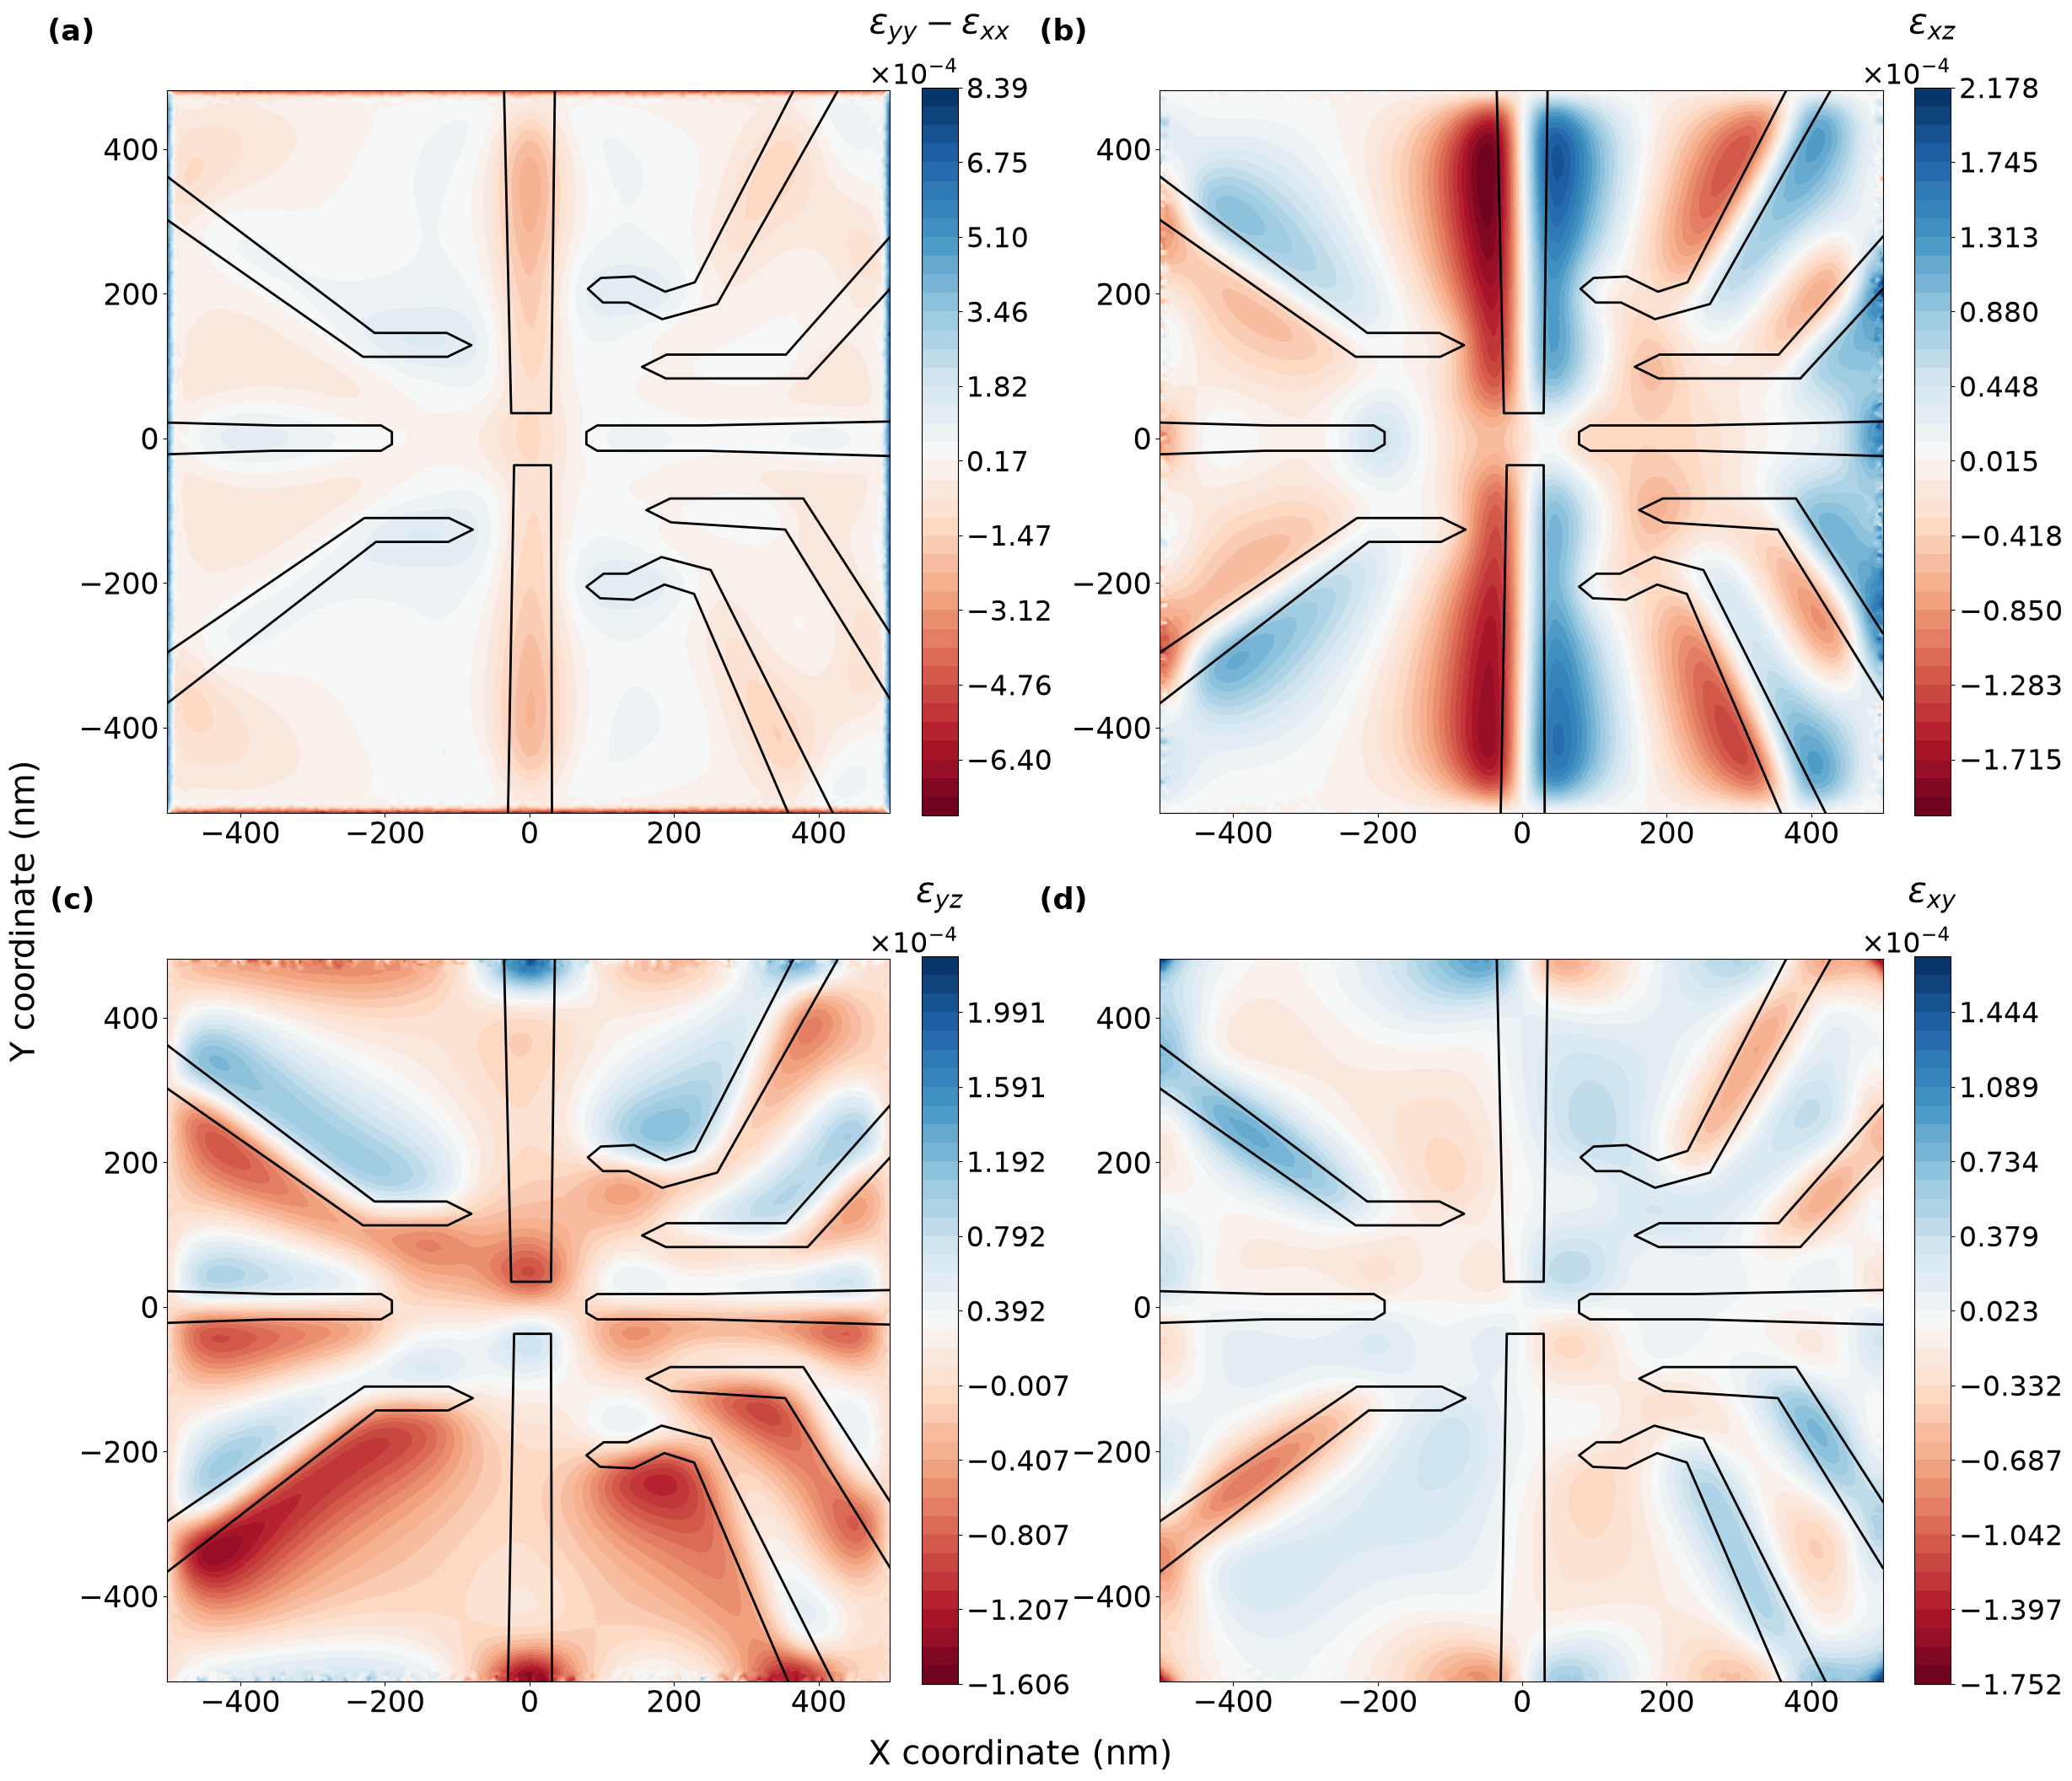

In [15]:
# ==========================
# Configuration Variables
# ==========================

# Axis properties
AXIS_TICK_SIZE = 25        # Size of the axis ticks
AXIS_LABEL_SIZE = 29       # Size of the axis labels

# Colorbar properties
COLORBAR_LABEL_SIZE = 30   # Size of the colorbar label
COLORBAR_TICK_SIZE = 24 # Size of the colorbar ticks
COLORBAR_OFFSET_TEXT_SIZE = 24  # Size of the colorbar scientific notation (e.g., 10^-4)

# Subplot label properties
SUBPLOT_LABEL_SIZE = 25
SUBPLOT_LABEL_FONTWEIGHT = 'bold'

# ==========================
# Plotting Function
# ==========================

def format_colorbar(cbar, label):
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_SIZE)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    if cbar.ax.yaxis.offsetText:
        cbar.ax.yaxis.offsetText.set_fontsize(COLORBAR_OFFSET_TEXT_SIZE)
    cbar.ax.set_title(label, fontsize=COLORBAR_LABEL_SIZE, pad=20, loc='center')

# ==========================
# Define Gates Coordinates
# ==========================

coordinate_groups = {
    'Gate 1': [
        (359.2, -410), (229, -107), (188, -94), (145, -115), (99, -113),
        (80, -97), (104, -79), (137, -79), (184, -56), (252, -74), (420.9, -410)
    ],
    'Gate 2': [
        (500, -252.5), (355, -18), (197, -8), (163, 9), (196, 25),
        (380, 25), (500, -161.2)
    ],
    'Gate 3': [
        (500, 83.7), (246, 91), (95, 91), (80, 100), (80, 117),
        (95, 126), (240, 126), (500, 131.5)
    ],
    'Gate 4': [
        (500, 314.9), (386, 191), (190, 191), (157, 207), (191, 224),
        (356, 224), (500, 387)
    ],
    'Gate 5': [
        (428.2, 590), (261, 294), (185, 273), (138, 296), (103, 296),
        (82, 315), (100, 330), (146, 332), (189, 311), (230, 324), (366.8, 590)
    ],
    'Gate 6': [
        (32.4, -410), (31, 71), (-20, 71), (-28.4, -410)
    ],
    'Gate 7': [
        (36.4, 590), (31, 143), (-24, 143), (-33.9, 590)
    ],
    'Gate 8': [
        (-500, -258.5), (-211, -35), (-111, -35), (-77, -18),
        (-110, -2), (-227, -2), (-500, -188.4)
    ],
    'Gate 9': [
        (-500, 86.1), (-355, 91), (-204, 91), (-189, 100),
        (-189, 117), (-204, 126), (-349, 126), (-500, 130)
    ],
    'Gate 10': [
        (-500, 410.6), (-229, 221), (-112, 221), (-79, 237),
        (-113, 254), (-213, 254), (-500, 470.5)
    ]
}

# Apply coordinate shifts to the GATE coordinates (not the data):
# the gate polygons above are defined in the raw Gmsh layout frame, while
# the imported strain CSVs are already in the shifted/exported frame
# (data x = mesh_x - 1.25, y = mesh_y - 108.05, applied at export time).
# Shifting x and y of the gates by the same amounts aligns the overlay
# with the data. (z is not used in these 2D overlays.)
shift_x = -1.25
shift_y = -108.05
shifted_coordinate_groups = {
    gate_label: [(x + shift_x, y + shift_y) for x, y in coords]
    for gate_label, coords in coordinate_groups.items()
}

# ==========================
# Create Subplots
# ==========================

fig, axs = plt.subplots(2, 2, figsize=(25, 22))

strain_keys = ['strain_yymxx', 'strain_xz', 'strain_yz', 'strain_xy']
colorbar_labels = [
    r'$\epsilon_{yy} - \epsilon_{xx}$',
    r'$\epsilon_{xz}$',
    r'$\epsilon_{yz}$',
    r'$\epsilon_{xy}$'
]

# Assuming 'strain_data' is defined elsewhere as:
# strain_data = {
#     'strain_yymxx': pd.DataFrame({'x': [...], 'y': [...], 'strain_value': [...] }),
#     'strain_xz': pd.DataFrame({'x': [...], 'y': [...], 'strain_value': [...] }),
#     ...
# }

# Create a grid based on the first strain component
first_strain_key = strain_keys[0]
x_unique = np.sort(strain_data[first_strain_key]['x'].unique())
y_unique = np.sort(strain_data[first_strain_key]['y'].unique())
X, Y = np.meshgrid(x_unique, y_unique)

for i, (strain_key, ax, label) in enumerate(zip(strain_keys, axs.flat, colorbar_labels)):
    # Sort and reshape strain data
    data_sorted = strain_data[strain_key].sort_values(by=['y', 'x'])
    Z = data_sorted['strain_value'].values.reshape(X.shape)

    # Define contour levels from min to max
    min_Z = np.min(Z)
    max_Z = np.max(Z)
    levels = np.linspace(min_Z, max_Z, 40)

    # Plot contour
    contour = ax.contourf(X, Y, Z, levels=levels, cmap='RdBu')
    cbar = fig.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
    format_colorbar(cbar, label)

    # Set tick parameters and aspect ratio
    ax.tick_params(axis='both', which='major', labelsize=AXIS_TICK_SIZE)
    ax.set_aspect('equal', 'box')

    # Plot gates
    for shifted_coords in shifted_coordinate_groups.values():
        line_x, line_y = zip(*shifted_coords)
        ax.plot(
            line_x, line_y,
            color='black',
            linestyle='-',
            linewidth=2
        )

    # Add subplot label
    subplot_label = chr(97 + i)  # 'a', 'b', 'c', 'd'
    ax.text(-0.1, 1.1, f'({subplot_label})', transform=ax.transAxes,
            fontsize=SUBPLOT_LABEL_SIZE, fontweight=SUBPLOT_LABEL_FONTWEIGHT,
            va='top', ha='right')

    # Remove individual axis labels
    ax.set_xlabel('')
    ax.set_ylabel('')

# Add shared axis labels
fig.text(0.5, 0.04, 'X coordinate (nm)', ha='center', fontsize=AXIS_LABEL_SIZE)
fig.text(0.02, 0.5, 'Y coordinate (nm)', va='center', rotation='vertical', fontsize=AXIS_LABEL_SIZE)

# Adjust layout and save
plt.tight_layout(rect=[0.05, 0.05, 1, 1], h_pad=0, w_pad=0.6)
plt.savefig(os.path.join(GRAPH_DIR, 'strain_distribution.pdf'), format='pdf', dpi=300)
plt.show()

# G-factor calculation and plotting

In [16]:
# Define Lattice Parameters
b = -2.160
k = 3.410
d = -6.060

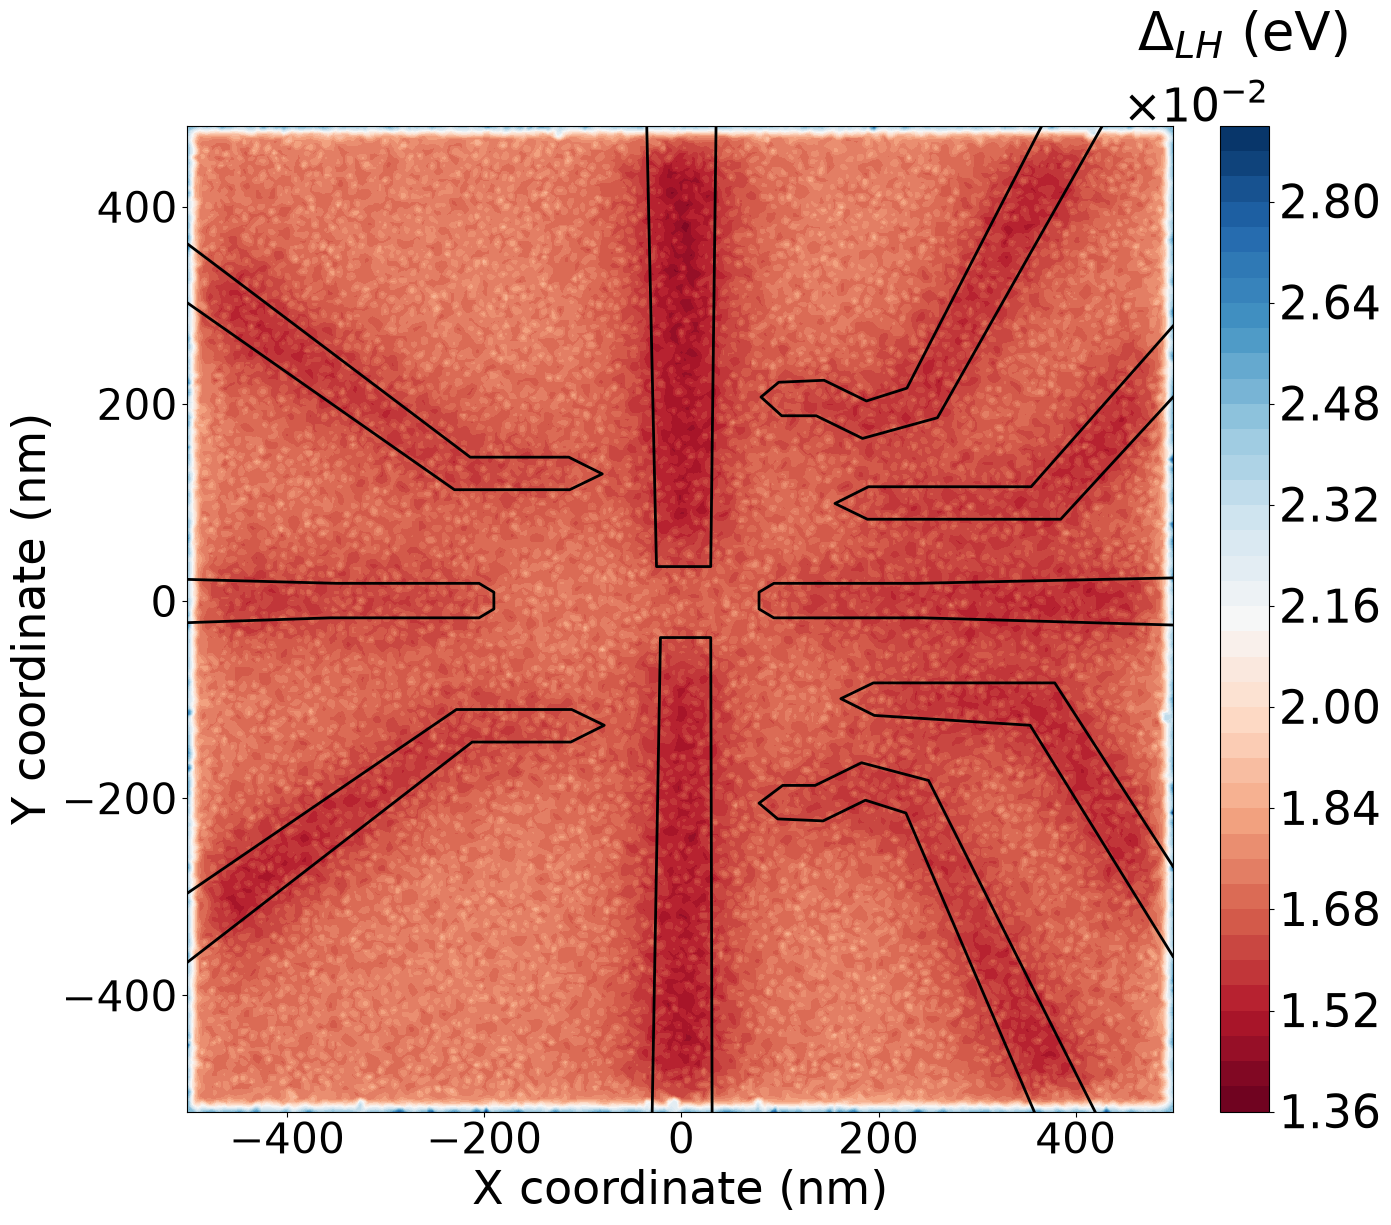

In [17]:
# ==========================
# Configuration Variables
# ==========================

# Axis properties
AXIS_TICK_SIZE = 30        # Size of the axis ticks
AXIS_LABEL_SIZE = 33       # Size of the axis labels

# Colorbar properties
COLORBAR_LABEL_SIZE = 38   # Size of the colorbar label
COLORBAR_TICK_SIZE = 33    # Size of the colorbar ticks
COLORBAR_OFFSET_TEXT_SIZE = 33  # Size of the colorbar scientific notation (e.g., 10^-4)

# ==========================
# Plotting Function
# ==========================

def format_colorbar(cbar, label):
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_SIZE)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    if cbar.ax.yaxis.offsetText:
        cbar.ax.yaxis.offsetText.set_fontsize(COLORBAR_OFFSET_TEXT_SIZE)
    cbar.ax.set_title(label, fontsize=COLORBAR_LABEL_SIZE, pad=20, loc='center')

# ==========================
# Define Gates Coordinates
# ==========================

coordinate_groups = {
    'Gate 1': [
        (359.2, -410), (229, -107), (188, -94), (145, -115), (99, -113),
        (80, -97), (104, -79), (137, -79), (184, -56), (252, -74), (420.9, -410)
    ],
    'Gate 2': [
        (500, -252.5), (355, -18), (197, -8), (163, 9), (196, 25),
        (380, 25), (500, -161.2)
    ],
    'Gate 3': [
        (500, 83.7), (246, 91), (95, 91), (80, 100), (80, 117),
        (95, 126), (240, 126), (500, 131.5)
    ],
    'Gate 4': [
        (500, 314.9), (386, 191), (190, 191), (157, 207), (191, 224),
        (356, 224), (500, 387)
    ],
    'Gate 5': [
        (428.2, 590), (261, 294), (185, 273), (138, 296), (103, 296),
        (82, 315), (100, 330), (146, 332), (189, 311), (230, 324), (366.8, 590)
    ],
    'Gate 6': [
        (32.4, -410), (31, 71), (-20, 71), (-28.4, -410)
    ],
    'Gate 7': [
        (36.4, 590), (31, 143), (-24, 143), (-33.9, 590)
    ],
    'Gate 8': [
        (-500, -258.5), (-211, -35), (-111, -35), (-77, -18),
        (-110, -2), (-227, -2), (-500, -188.4)
    ],
    'Gate 9': [
        (-500, 86.1), (-355, 91), (-204, 91), (-189, 100),
        (-189, 117), (-204, 126), (-349, 126), (-500, 130)
    ],
    'Gate 10': [
        (-500, 410.6), (-229, 221), (-112, 221), (-79, 237),
        (-113, 254), (-213, 254), (-500, 470.5)
    ]
}

# Apply coordinate shifts to the GATE coordinates (not the data):
# the gate polygons above are defined in the raw Gmsh layout frame, while
# the imported strain CSVs are already in the shifted/exported frame
# (data x = mesh_x - 1.25, y = mesh_y - 108.05, applied at export time).
# Shifting x and y of the gates by the same amounts aligns the overlay
# with the data. (z is not used in these 2D overlays.)
shift_x = -1.25
shift_y = -108.05
shifted_coordinate_groups = {
    gate_label: [(x + shift_x, y + shift_y) for x, y in coords]
    for gate_label, coords in coordinate_groups.items()
}

# ==========================
# Compute LH-HH Band Gap
# ==========================

def compute_LH_HH_gap(constant_term, strain_yypxx, strain_zz, b):
    """
    Calculate the LH-HH band gap using the given constant term and strain components.

    Parameters:
    constant_term (float): The constant term in the gap equation.
    strain_yypxx (DataFrame): The strain data for (ε_xx + ε_yy).
    strain_zz (DataFrame): The strain data for ε_zz.
    b (float): Coefficient for the second term.

    Returns:
    gap (Series): The calculated LH-HH band gap distribution.
    """
    # Calculate the second term: (ε_xx + ε_yy) - 2 * ε_zz
    second_term = strain_yypxx['strain_value'] - 2 * strain_zz['strain_value']

    # Compute the total LH-HH band gap
    gap = constant_term + b * second_term

    return gap

# Define the constant term and ensure 'b' is defined elsewhere in your script
constant_term = 24.912e-3  # in eV
# b should be defined before this section, e.g., b = 1.0

# Ensure strain_yypxx and strain_zz are sorted by 'y' and 'x' for correct reshaping
strain_yypxx_sorted = strain_data['strain_yypxx'].sort_values(by=['y', 'x'])
strain_zz_sorted = strain_data['strain_zz'].sort_values(by=['y', 'x'])

# Calculate the gap distribution
delta_LH = compute_LH_HH_gap(constant_term, strain_yypxx_sorted, strain_zz_sorted, b)

# ==========================
# Reshape for Plotting
# ==========================

x_unique = np.sort(strain_yypxx_sorted['x'].unique())
y_unique = np.sort(strain_yypxx_sorted['y'].unique())
X, Y = np.meshgrid(x_unique, y_unique)
Z = delta_LH.values.reshape(X.shape)

# ==========================
# Plot the LH-HH Band Gap with Gates
# ==========================

plt.figure(figsize=(15, 13))

# Create contour plot with the 'RdBu' colormap
contour = plt.contourf(X, Y, Z, levels=40, cmap='RdBu')

# Add colorbar
cbar = plt.colorbar(contour, fraction=0.046, pad=0.04)
format_colorbar(cbar, r'$\Delta_{LH}$ (eV)')  # LaTeX formatted label

# Set axis labels
plt.xlabel('X coordinate (nm)', fontsize=AXIS_LABEL_SIZE)
plt.ylabel('Y coordinate (nm)', fontsize=AXIS_LABEL_SIZE)

# Set axis tick label size
plt.xticks(fontsize=AXIS_TICK_SIZE)
plt.yticks(fontsize=AXIS_TICK_SIZE)

# Set aspect ratio to be equal
plt.gca().set_aspect('equal', adjustable='box')

# Plot each group of shifted coordinates as a black solid line
for shifted_coords in shifted_coordinate_groups.values():
    line_x, line_y = zip(*shifted_coords)
    plt.plot(line_x, line_y, color='black', linestyle='-', linewidth=2)

# Optional: Add a single label if needed (e.g., 'a'), but per user request, it's omitted
# Remove subplot label code

# Adjust layout and save the figure
plt.tight_layout(rect=[0.05, 0.05, 1, 1], h_pad=0, w_pad=0.6)
plt.savefig(os.path.join(GRAPH_DIR, 'LH-HH_band_gap.pdf'), format='pdf', dpi=300)

# Optionally, display the plot
plt.show()


## Strain-induced g-tensor corrections

The corrections implemented below are (with $b \equiv b_v$, $k \equiv \kappa$, $d \equiv d_v$):

$$\delta g_{xx} = \delta g_{yy} = \frac{6 b_v \kappa}{\Delta_{LH}} \left( \langle\epsilon_{yy}\rangle - \langle\epsilon_{xx}\rangle \right) \tag{9}$$

$$\delta g_{zy} = -\frac{4\sqrt{3} \kappa d_v}{\Delta_{LH}} \langle\epsilon_{yz}\rangle \tag{10}$$

$$\delta g_{zx} = -\frac{4\sqrt{3} \kappa d_v}{\Delta_{LH}} \langle\epsilon_{xz}\rangle \tag{11}$$

$$\delta g_{xy} = -\delta g_{yx} = \frac{4\sqrt{3} d_v \kappa}{\Delta_{LH}} \langle\epsilon_{xy}\rangle \tag{12}$$

Here the angle brackets $\langle\cdot\rangle$ are replaced by the local (site-dependent) strain values, and $\Delta_{LH}$ is the site-dependent LH-HH band gap computed above.

In [18]:
# Define the function to calculate the site-dependent g_xx or g_yy correction
def g_xx_func(eps_yymxx, delta_LH):
    """
    Calculate the g_xx correction using the strain components and site-dependent delta_LH.

    Parameters:
    eps_yymxx (array-like): Strain component (ε_yy − ε_xx).
    delta_LH (array-like): Site-dependent LH-HH band gap.

    Returns:
    g_xx (array-like): g_xx correction for each site.
    """
    g_xx = (6 * b * k * eps_yymxx) / delta_LH
    return g_xx

# Define the function to calculate the site-dependent g_zx correction
def g_zx_func(eps_xz, delta_LH):
    """
    Calculate the g_zx correction using the strain components and site-dependent delta_LH.

    Parameters:
    eps_xz (array-like): Strain component ε_xz.
    delta_LH (array-like): Site-dependent LH-HH band gap.

    Returns:
    g_zx (array-like): g_zx correction for each site.
    """
    g_zx = (-4 * np.sqrt(3) * d * k * eps_xz) / delta_LH
    return g_zx

# Define the function to calculate the site-dependent g_zy correction
def g_zy_func(eps_yz, delta_LH):
    """
    Calculate the g_zy correction using the strain components and site-dependent delta_LH.

    Parameters:
    eps_yz (array-like): Strain component ε_yz.
    delta_LH (array-like): Site-dependent LH-HH band gap.

    Returns:
    g_zy (array-like): g_zy correction for each site.
    """
    g_zy = (-4 * np.sqrt(3) * d * k * eps_yz) / delta_LH
    return g_zy

# Define the function to calculate the site-dependent g_xy correction
def g_xy_func(eps_xy, delta_LH):
    """
    Calculate the g_xy correction using the strain components and site-dependent delta_LH.

    Parameters:
    eps_xy (array-like): Strain component ε_xy.
    delta_LH (array-like): Site-dependent LH-HH band gap.

    Returns:
    g_xy (array-like): g_xy correction for each site.
    """
    g_xy = (4 * np.sqrt(3) * d * k * eps_xy) / delta_LH
    return g_xy


In [19]:
# Create a new DataFrame for g_xx values and coordinates using site-dependent delta_LH
g_xx_data = pd.DataFrame({
    'x': strain_data['strain_yymxx']['x'],
    'y': strain_data['strain_yymxx']['y'],
    'g_xx': g_xx_func(strain_data['strain_yymxx']['strain_value'], delta_LH)
})

# Create a new DataFrame for g_zx values and coordinates using site-dependent delta_LH
g_zx_data = pd.DataFrame({
    'x': strain_data['strain_xz']['x'],
    'y': strain_data['strain_xz']['y'],
    'g_zx': g_zx_func(strain_data['strain_xz']['strain_value'], delta_LH)
})

# Create a new DataFrame for g_zy values and coordinates using site-dependent delta_LH
g_zy_data = pd.DataFrame({
    'x': strain_data['strain_yz']['x'],
    'y': strain_data['strain_yz']['y'],
    'g_zy': g_zy_func(strain_data['strain_yz']['strain_value'], delta_LH)
})

# Create a new DataFrame for g_xy values and coordinates using site-dependent delta_LH
g_xy_data = pd.DataFrame({
    'x': strain_data['strain_xy']['x'],
    'y': strain_data['strain_xy']['y'],
    'g_xy': g_xy_func(strain_data['strain_xy']['strain_value'], delta_LH)
})


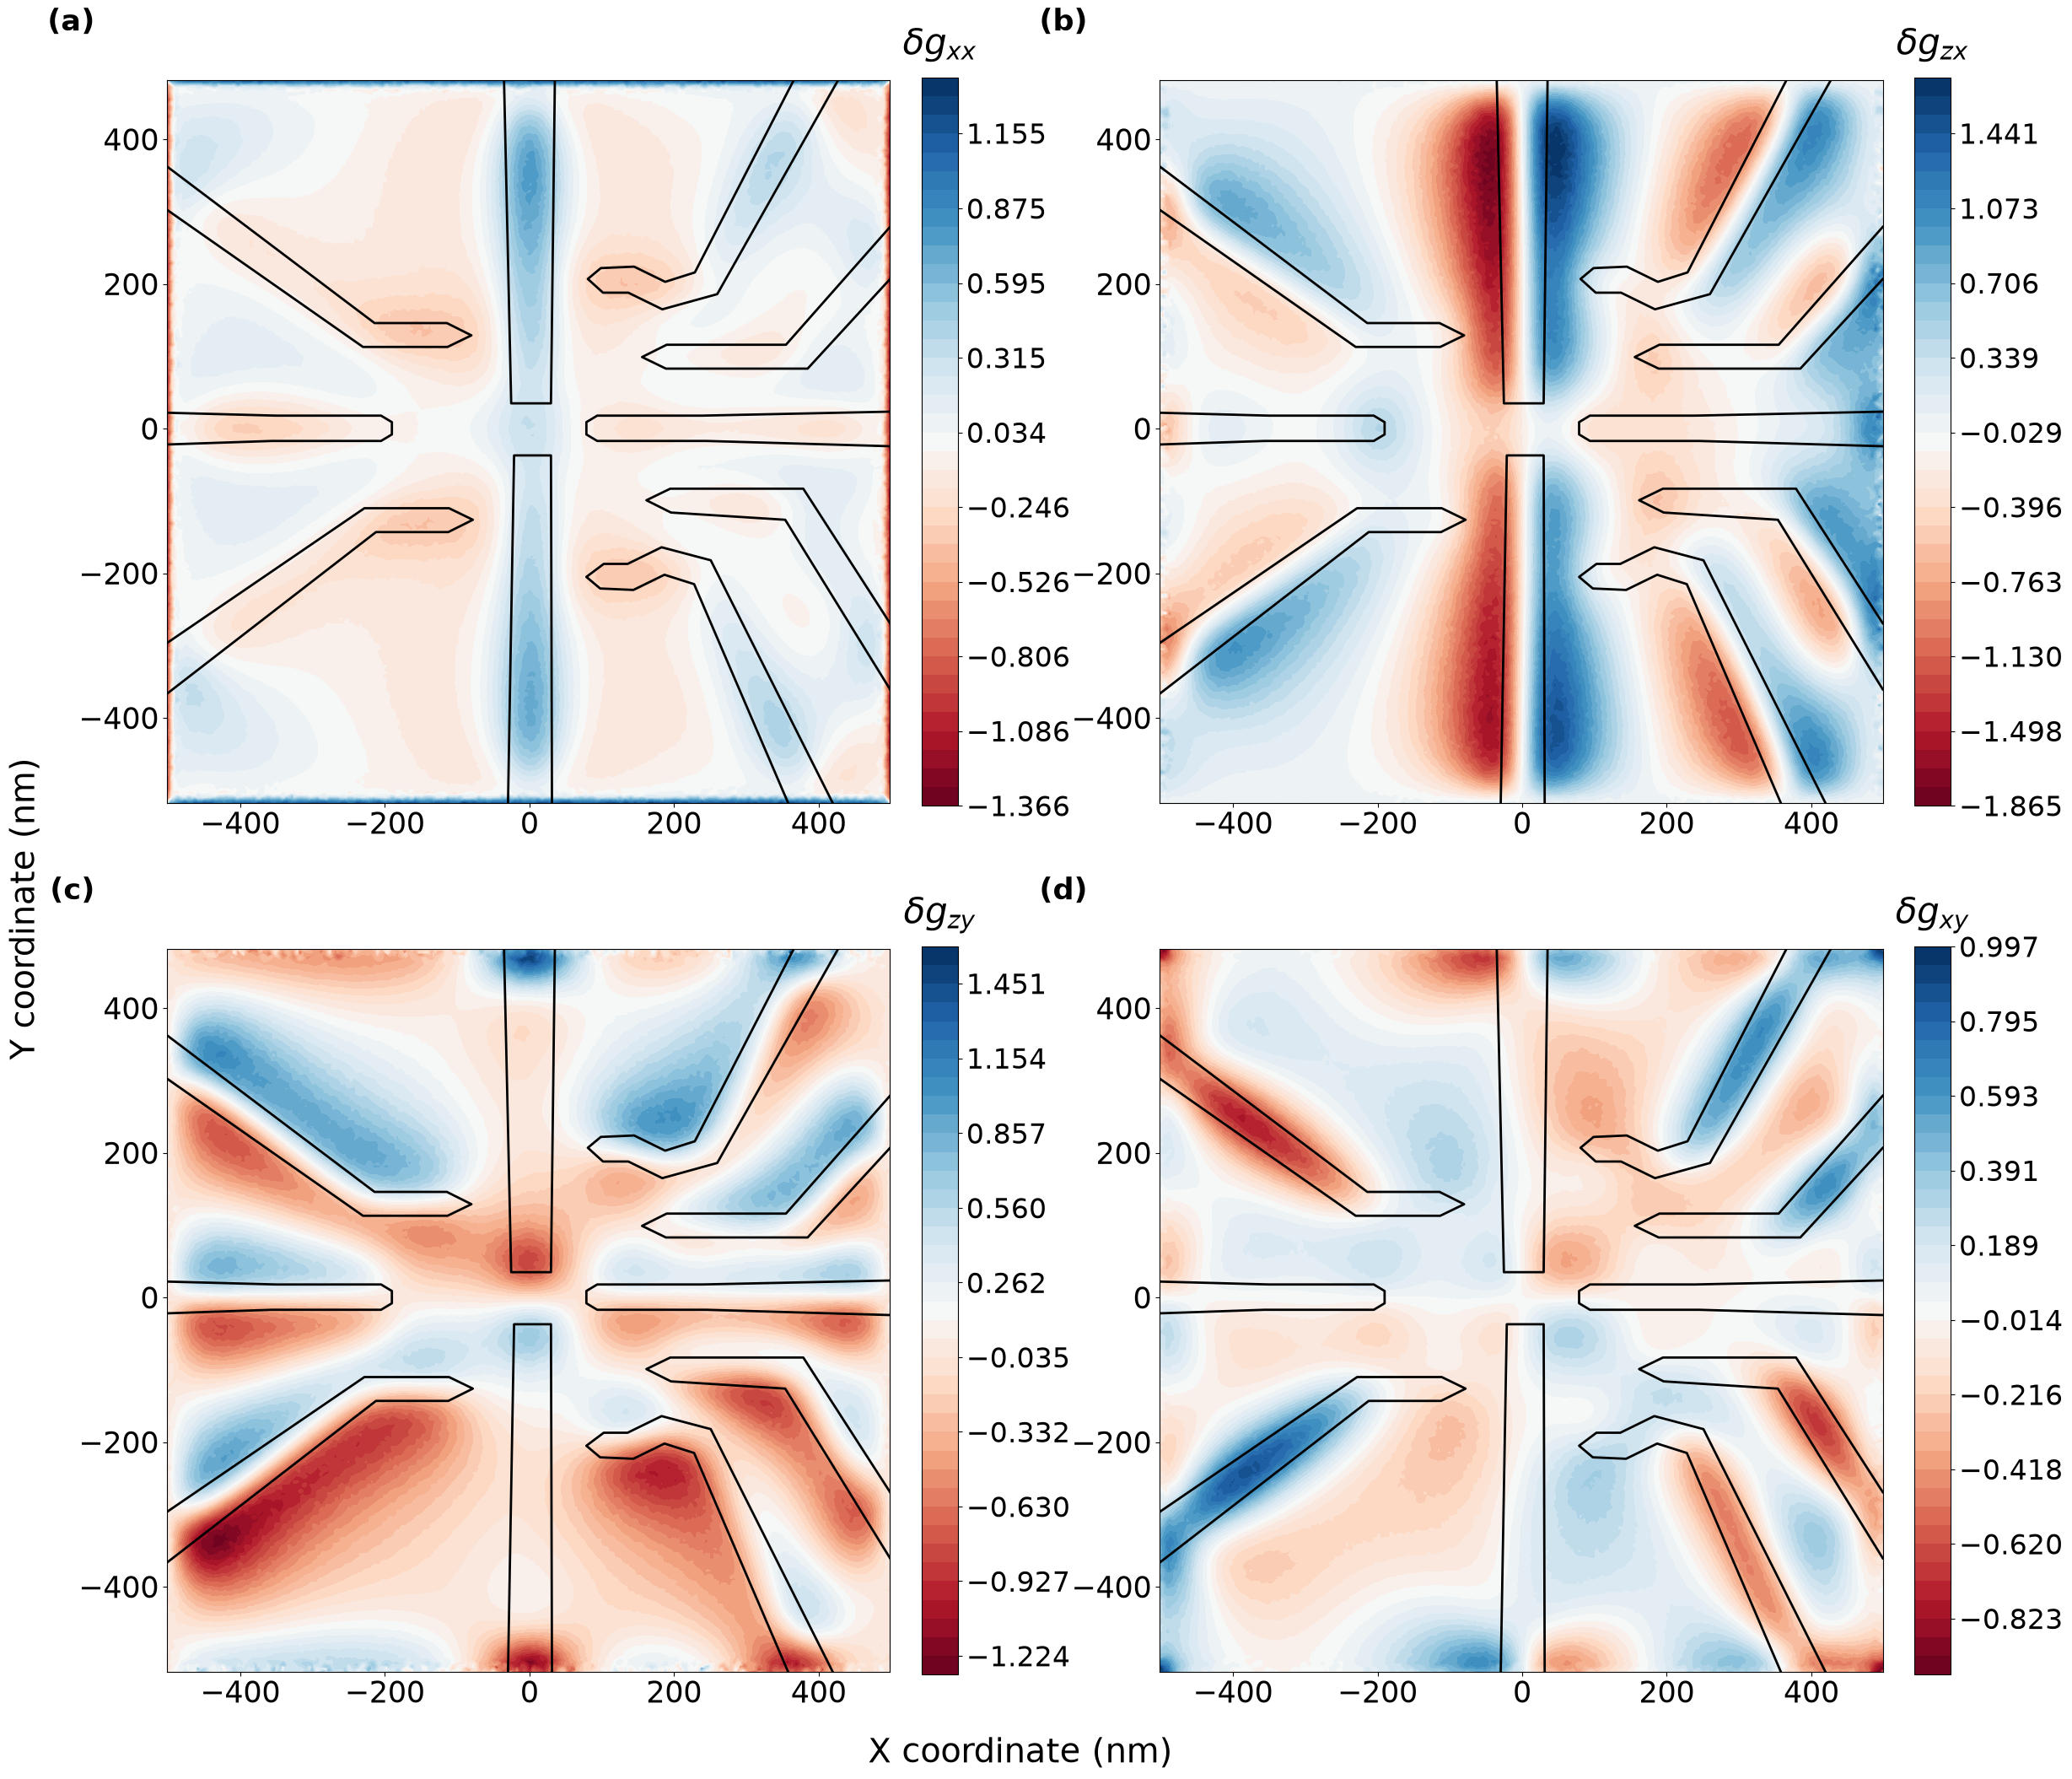

In [20]:

# ==========================
# Configuration Variables
# ==========================

# Axis properties
AXIS_TICK_SIZE = 25        # Size of the axis ticks
AXIS_LABEL_SIZE = 29       # Size of the axis labels

# Colorbar properties
COLORBAR_LABEL_SIZE = 30   # Size of the colorbar label
COLORBAR_TICK_SIZE = 24    # Size of the colorbar ticks
COLORBAR_OFFSET_TEXT_SIZE = 24  # Size of the colorbar scientific notation (e.g., 10^-4)

# Subplot label properties
SUBPLOT_LABEL_SIZE = 25
SUBPLOT_LABEL_FONTWEIGHT = 'bold'

# ==========================
# Plotting Function
# ==========================

def format_colorbar(cbar, label):
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_SIZE)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    if cbar.ax.yaxis.offsetText:
        cbar.ax.yaxis.offsetText.set_fontsize(COLORBAR_OFFSET_TEXT_SIZE)
    cbar.ax.set_title(label, fontsize=COLORBAR_LABEL_SIZE, pad=20, loc='center')

# ==========================
# Define Gates Coordinates
# ==========================

coordinate_groups = {
    'Gate 1': [
        (359.2, -410), (229, -107), (188, -94), (145, -115), (99, -113),
        (80, -97), (104, -79), (137, -79), (184, -56), (252, -74), (420.9, -410)
    ],
    'Gate 2': [
        (500, -252.5), (355, -18), (197, -8), (163, 9), (196, 25),
        (380, 25), (500, -161.2)
    ],
    'Gate 3': [
        (500, 83.7), (246, 91), (95, 91), (80, 100), (80, 117),
        (95, 126), (240, 126), (500, 131.5)
    ],
    'Gate 4': [
        (500, 314.9), (386, 191), (190, 191), (157, 207), (191, 224),
        (356, 224), (500, 387)
    ],
    'Gate 5': [
        (428.2, 590), (261, 294), (185, 273), (138, 296), (103, 296),
        (82, 315), (100, 330), (146, 332), (189, 311), (230, 324), (366.8, 590)
    ],
    'Gate 6': [
        (32.4, -410), (31, 71), (-20, 71), (-28.4, -410)
    ],
    'Gate 7': [
        (36.4, 590), (31, 143), (-24, 143), (-33.9, 590)
    ],
    'Gate 8': [
        (-500, -258.5), (-211, -35), (-111, -35), (-77, -18),
        (-110, -2), (-227, -2), (-500, -188.4)
    ],
    'Gate 9': [
        (-500, 86.1), (-355, 91), (-204, 91), (-189, 100),
        (-189, 117), (-204, 126), (-349, 126), (-500, 130)
    ],
    'Gate 10': [
        (-500, 410.6), (-229, 221), (-112, 221), (-79, 237),
        (-113, 254), (-213, 254), (-500, 470.5)
    ]
}

# Apply coordinate shifts to the GATE coordinates (not the data):
# the gate polygons above are defined in the raw Gmsh layout frame, while
# the imported strain CSVs are already in the shifted/exported frame
# (data x = mesh_x - 1.25, y = mesh_y - 108.05, applied at export time).
# Shifting x and y of the gates by the same amounts aligns the overlay
# with the data. (z is not used in these 2D overlays.)
shift_x = -1.25
shift_y = -108.05
shifted_coordinate_groups = {
    gate_label: [(x + shift_x, y + shift_y) for x, y in coords]
    for gate_label, coords in coordinate_groups.items()
}

# ==========================
# Create Subplots
# ==========================

fig, axs = plt.subplots(2, 2, figsize=(25, 22))

strain_keys = ['g_xx', 'g_zx', 'g_zy', 'g_xy']
colorbar_labels = [
    r'$\delta g_{xx}$',
    r'$\delta g_{zx}$',
    r'$\delta g_{zy}$',
    r'$\delta g_{xy}$'
]

# ==========================
# Define g-correction DataFrames
# ==========================

# List of g-correction DataFrames
g_correction_data = [g_xx_data, g_zx_data, g_zy_data, g_xy_data]

# Create a grid based on the first g-correction component
first_g_key = strain_keys[0]
x_unique = np.sort(g_correction_data[0]['x'].unique())
y_unique = np.sort(g_correction_data[0]['y'].unique())
X, Y = np.meshgrid(x_unique, y_unique)

# ==========================
# Plotting Loop
# ==========================

for i, (g_data, ax, label) in enumerate(zip(g_correction_data, axs.flat, colorbar_labels)):
    # Sort and reshape g-correction data
    data_sorted = g_data.sort_values(by=['y', 'x'])
    Z = data_sorted.iloc[:, 2].values.reshape(X.shape)  # Assuming third column is g-correction

    # Define contour levels from min to max
    min_Z = np.min(Z)
    max_Z = np.max(Z)
    levels = np.linspace(min_Z, max_Z, 40)

    # Plot contour
    contour = ax.contourf(X, Y, Z, levels=levels, cmap='RdBu')
    cbar = fig.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
    format_colorbar(cbar, label)

    # Set tick parameters and aspect ratio
    ax.tick_params(axis='both', which='major', labelsize=AXIS_TICK_SIZE)
    ax.set_aspect('equal', 'box')

    # Plot gates as black solid lines
    for shifted_coords in shifted_coordinate_groups.values():
        line_x, line_y = zip(*shifted_coords)
        ax.plot(
            line_x, line_y,
            color='black',
            linestyle='-',
            linewidth=2
        )

    # Add subplot label
    subplot_label = chr(97 + i)  # 'a', 'b', 'c', 'd'
    ax.text(-0.1, 1.1, f'({subplot_label})', transform=ax.transAxes,
            fontsize=SUBPLOT_LABEL_SIZE, fontweight=SUBPLOT_LABEL_FONTWEIGHT,
            va='top', ha='right')

    # Remove individual axis labels
    ax.set_xlabel('')
    ax.set_ylabel('')

# ==========================
# Add Shared Axis Labels
# ==========================

fig.text(0.5, 0.04, 'X coordinate (nm)', ha='center', fontsize=AXIS_LABEL_SIZE)
fig.text(0.02, 0.5, 'Y coordinate (nm)', va='center', rotation='vertical', fontsize=AXIS_LABEL_SIZE)

# ==========================
# Adjust Layout and Save
# ==========================

plt.tight_layout(rect=[0.05, 0.05, 1, 1], h_pad=0, w_pad=0.6)
plt.savefig(os.path.join(GRAPH_DIR, 'g_tensor_correction.pdf'), format='pdf', dpi=300)
plt.show()
